In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
path="C:/Users/HP/Data Science/myOne_reviews_cleaned.csv"
df=pd.read_csv(path)
df.head()

,username,rating,review_text,date,sentiment,cleaned_reviews,tokens
0,Bekham Oyugi,1,Worst update ever you can do better,2026-06-03 21:26:34,Negative,worst update ever you can do better,"['worst', 'update', 'ever', 'you', 'can', 'do'..."
1,Ndungu John John,3,my hakikisha is not working today,2026-06-03 18:47:40,Negative,my hakikisha is not working today,"['my', 'hakikisha', 'is', 'not', 'working', 't..."
2,Winnie Kinyua,5,The tech team doing better. But would do more ...,2026-06-03 17:42:46,Positive,the tech team doing better but would do more o...,"['the', 'tech', 'team', 'doing', 'better', 'bu..."
3,Isaa William,5,nice app I have ever seen,2026-06-03 16:26:29,Positive,nice app i have ever seen,"['nice', 'app', 'i', 'have', 'ever', 'seen']"
4,Peter Murengi,5,it's a very useful app,2026-06-03 15:01:26,Positive,its a very useful app,"['its', 'a', 'very', 'useful', 'app']"


In [3]:
df = df[['cleaned_reviews', 'sentiment']]
df.head()

,cleaned_reviews,sentiment
0,worst update ever you can do better,Negative
1,my hakikisha is not working today,Negative
2,the tech team doing better but would do more o...,Positive
3,nice app i have ever seen,Positive
4,its a very useful app,Positive


In [4]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['cleaned_reviews'])
sequences = tokenizer.texts_to_sequences(df['cleaned_reviews'])

In [5]:
#apply padding
lengths = [len(seq) for seq in sequences]

print(f"Average length: {int(sum(lengths) / len(lengths))}")
print(f"Maximum length: {max(lengths)}")
print(f"Minimum length: {min(lengths)}")

from tensorflow.keras.preprocessing.sequence import pad_sequences

pad=pad_sequences(sequences,maxlen=50,padding='post')
print(pad.shape)

Average length: 9
Maximum length: 100
Minimum length: 0
(25920, 50)


In [21]:
from tensorflow.keras import layers, models, regularizers, metrics
from tensorflow.keras.callbacks import EarlyStopping

# Define a network integrating L2 regularizers and Dropout layers
model = models.Sequential([
    layers.Embedding(input_dim=5000, output_dim=32),
    layers.Bidirectional(layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    
    layers.Dense(32, activation='relu', 
                 kernel_regularizer=regularizers.l1(0.01)), # L1 alternative
    layers.Dropout(0.2),
    
    layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

# Implement Early Stopping to stop training when validation loss plateaus
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X=pad
y=df['sentiment'].map({'Negative':0, 'Positive':1})

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_test, y_test), 
    epochs=20,
    callbacks=[early_stop]
)
# 6. SECOND: Evaluate performance
print("\n--- Evaluating Model Performance ---")
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
#predict
predictions=model.predict(X_test)

Epoch 1/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.8225 - loss: 0.8299 - val_accuracy: 0.8727 - val_loss: 0.4017
Epoch 2/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.8807 - loss: 0.3911 - val_accuracy: 0.8769 - val_loss: 0.3732
Epoch 3/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.8912 - loss: 0.3596 - val_accuracy: 0.8754 - val_loss: 0.3651
Epoch 4/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.8967 - loss: 0.3404 - val_accuracy: 0.8775 - val_loss: 0.3631
Epoch 5/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 44s 67ms/step - accuracy: 0.9013 - loss: 0.3291 - val_accuracy: 0.8752 - val_loss: 0.3620
Epoch 6/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 50s 76ms/step - accuracy: 0.9069 - loss: 0.3186 - val_accuracy: 0.8750 - val_loss: 0.3661
Epoch 7/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.9105 - loss: 0.3097 - val_accuracy: 0.8719 - val_loss: 0.3736
Epoch 8/20
648/648 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.9126 - loss: 0.3023 - 

In [24]:
from tensorflow.keras.utils import pad_sequences

def check_review_sentiment(review, tokenizer, model, max_length=50):
    """
    Processes a raw text review, makes a sentiment prediction,
    and prints out the final classification along with its confidence percentage.
    """
    # 1. Convert text to sequence and pad it to match the shape (50,)
    sequence = tokenizer.texts_to_sequences([review])
    padded = pad_sequences(sequence, maxlen=max_length, padding='post')
    
    # 2. Predict the raw probability score
    prediction = model.predict(padded, verbose=0)
    probability = prediction[0][0]
    
    # 3. Determine class and compute percentage confidence
    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability * 100
    else:
        sentiment = "Negative"
        confidence = (1 - probability) * 100
        
    # 4. Print the output directly
    print("-" * 50)
    print(f"Review Content : {review}")
    print(f"Predicted Class: {sentiment}")
    print(f"Confidence     : {confidence:.2f}%")
    print("-" * 50)

In [25]:
# Just call the function with your variables
check_review_sentiment("The latest update fixed all the bugs, thank you!", tokenizer, model)

--------------------------------------------------
Review Content : The latest update fixed all the bugs, thank you!
Predicted Class: Positive
Confidence     : 71.35%
--------------------------------------------------


In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Convert continuous probabilities into 0 or 1 binary classes
binary_predictions = (predictions >= 0.5).astype(int)

cm = confusion_matrix(y_test, binary_predictions)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 983  322]
 [ 325 3554]]


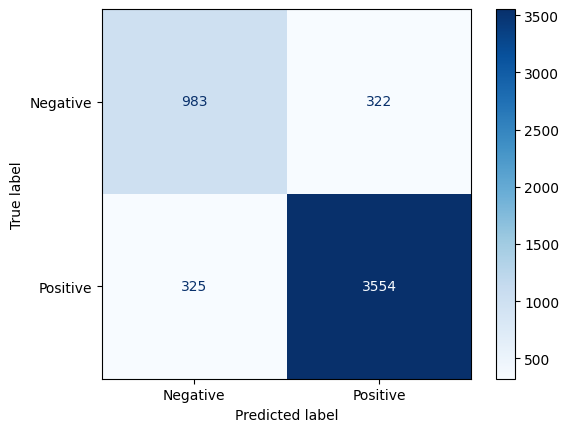

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display the matrix with your specific class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')

In [30]:
from sklearn.metrics import classification_report

# Print precision, recall, and f1-score
print(classification_report(y_test, binary_predictions, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75      1305
    Positive       0.92      0.92      0.92      3879

    accuracy                           0.88      5184
   macro avg       0.83      0.83      0.83      5184
weighted avg       0.88      0.88      0.88      5184

